In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Se pide, usando regresión lineal:

Dibujar con una línea la relación que hay entre la altura y la edad de los alumnos de esta clase: 

In [2]:
lista_alumnos = [("Leonardo S", 24, 1.82), 
                 ("Piero T", 25, 1.71), 
                 ("Marta B", 35, 1.66), 
                 ("Silvia P", 37, 1.63), 
                 ("Faro Z", 29, 1.90), 
                 ("Miguel N", 27, 1.80), 
                 ("Alejandro M", 28, 1.70), 
                 ("Cristina M", 32, 1.60), 
                 ("Francisco P", 36, 1.74), 
                 ("Jorge D", 45, 1.72), 
                 ("Jesús L", 41, 1.65), 
                 ("Marta G", 30, 1.65), 
                 ("Jennifer S", 40, 1.60), 
                 ("Diego I", 39, 1.80), 
                 ("Antonio C", 23, 1.77), 
                 ("Juan M", 32, 1.75), 
                 ("David S", 27, 1.70), 
                 ("Antonio J", 34, 1.80), 
                 ("Carlos H", 27, 1.77), 
                 ("Erik U", 28, 1.70), 
                 ("Marcos L", 35, 1.80)] 

In [3]:
df = pd.DataFrame(lista_alumnos, columns=['Nombre', 'Edad', 'Altura'])
df.head()
X = df[['Edad']]  
y = df[['Altura']]

from sklearn.linear_model import LinearRegression

modelo = LinearRegression()
modelo.fit(X, y)

df['prediccion'] = modelo.predict(X)

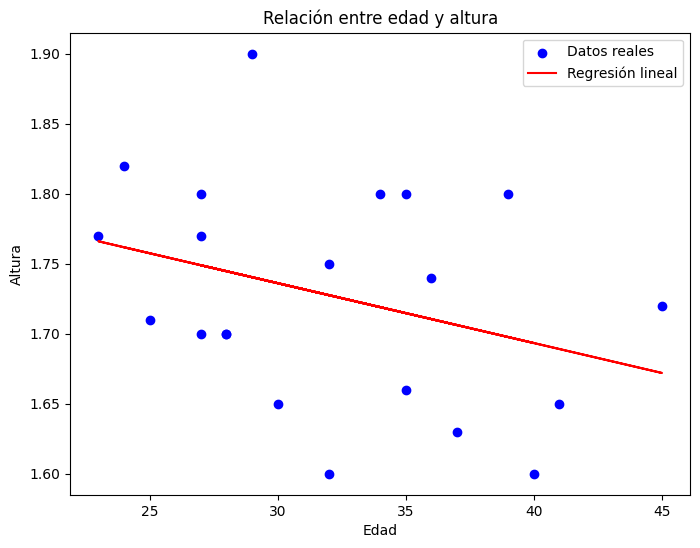

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# puntos reales
plt.scatter(df['Edad'], df['Altura'], color='blue', label='Datos reales')

# línea de regresión
plt.plot(df['Edad'], df['prediccion'], color='red', label='Regresión lineal')

plt.xlabel('Edad')
plt.ylabel('Altura')
plt.title('Relación entre edad y altura')
plt.legend()

plt.show()

### ¿Es una buena técnica para este tipo de problemas? Demuéstralo antes de entrenar un modelo con un análisis descriptivo.

In [7]:
#Sí, es recomendable realizar un análisis descriptivo antes de aplicar regresión lineal para comprobar si existe una relación entre variables.

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Nombre      21 non-null     str    
 1   Edad        21 non-null     int64  
 2   Altura      21 non-null     float64
 3   prediccion  21 non-null     float64
dtypes: float64(2), int64(1), str(1)
memory usage: 804.0 bytes


In [9]:
df[['Edad', 'Altura']].describe()

,Edad,Altura
count,21.000000,21.000000
mean,32.095238,1.727143
std,6.081980,0.079003
min,23.000000,1.600000
25%,27.000000,1.660000
50%,32.000000,1.720000
75%,36.000000,1.800000
max,45.000000,1.900000


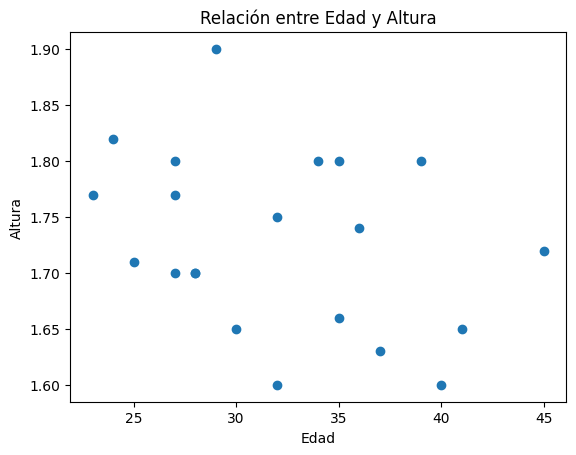

In [10]:
import matplotlib.pyplot as plt

plt.scatter(df['Edad'], df['Altura'])

plt.xlabel('Edad')
plt.ylabel('Altura')
plt.title('Relación entre Edad y Altura')

plt.show()

<Axes: xlabel='Edad', ylabel='Altura'>

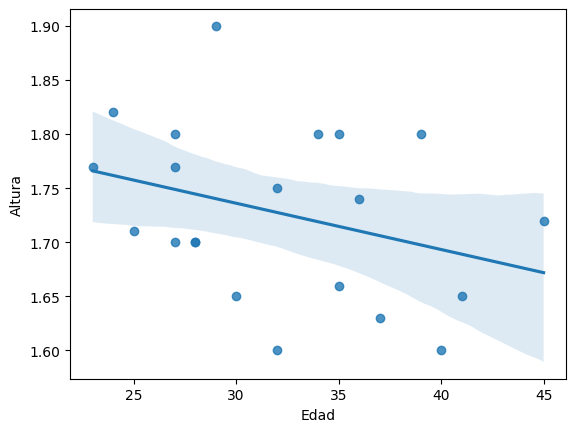

In [11]:
sns.regplot(x='Edad', y='Altura', data=df)

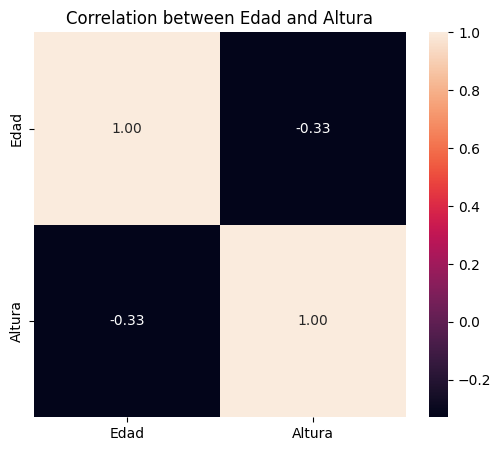

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# matriz de correlación
corr = df[['Edad', 'Altura']].corr()

# gráfico
plt.figure(figsize=(6, 5))

sns.heatmap(corr, annot=True, cmap='rocket', fmt='.2f')

plt.title('Correlation between Edad and Altura')
plt.show()

<Axes: >

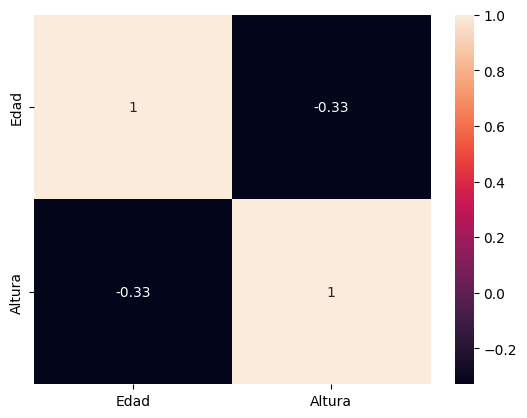

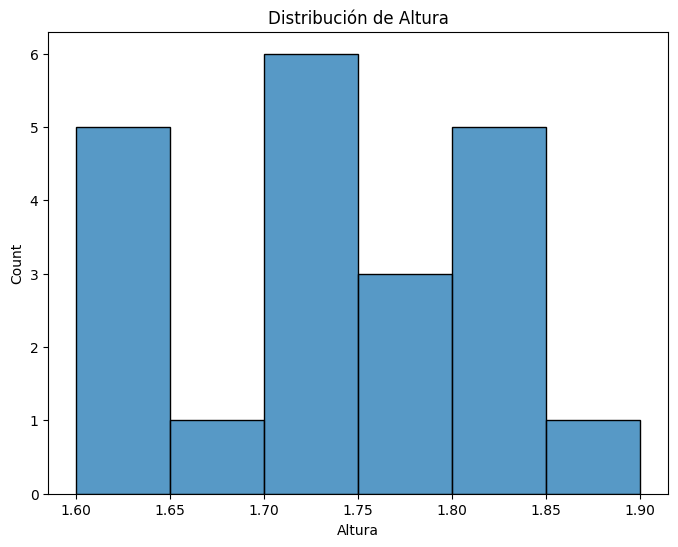

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.histplot(df['Altura'], bins=6)

plt.xlabel('Altura')
plt.ylabel('Count')
plt.title('Distribución de Altura')

plt.show()

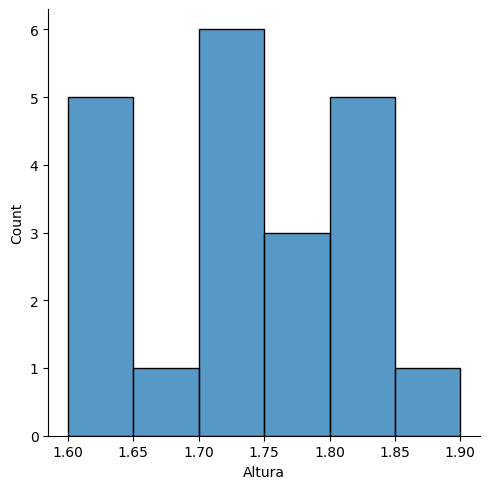

### Entrena un modelo de regresión lineal

In [14]:
X = df[['Edad']]   # variable independiente (input)
y = df['Altura']   # variable dependiente (output)

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=5, random_state=42)

In [16]:
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()

# entrenar
modelo.fit(X_train, y_train)

# sacar ecuación
a = modelo.intercept_
b = modelo.coef_[0]

print("Intercepto (a):", a)
print("Coeficiente (b):", b)

print(f"altura = {a:.3f} + {b:.3f} * Edad")

Intercepto (a): 1.858051298091961
Coeficiente (b): -0.004357209884266498
altura = 1.858 + -0.004 * Edad


(16, 1)
(5, 1)
(16,)
(5,)


y = a + b*x

altura = a + b*Edad

In [17]:
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()

modelo.fit(X_train, y_train)

modelo

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [41]:
print(modelo.intercept_)

1.858051298091961


In [18]:
modelo.coef_[0]

np.float64(-0.004357209884266498)

np.float64(-0.004357209884266498)

In [19]:
modelo.coef_

array([-0.00435721])

array([-0.00435721])

Altura = 1.86 - 0.004 * Edad

In [22]:
a = modelo.intercept_
b = modelo.coef_[0]

altura =(f"Altura = {a:.2f} {b:.3f} * Edad")

print(altura)

Altura = 1.86 -0.004 * Edad


1.7247000000000001


In [23]:
modelo.predict([[31]])

c:\Users\esthe\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([1.72297779])

In [24]:
modelo.predict([[31], [40], [20]])

c:\Users\esthe\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([1.72297779, 1.6837629 , 1.7709071 ])

c:\Users\Alberto Romero\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([1.72297779, 1.6837629 , 1.7709071 ])

### ¿Qué error se comete? Calcula los errores que está cometiendo tu modelo de forma manual con python. Aparte, usa las métricas de sklearn MAE, MAPE, MSE y el RMSE.

In [27]:
y_pred = modelo.predict(X_test)
print(y_pred)


[1.75347826 1.70990616 1.71862058 1.74912105 1.70119174]


array([1.75347826, 1.70990616, 1.71862058, 1.74912105, 1.70119174])

In [28]:
print(y_test)

0     1.82
17    1.80
15    1.75
1     1.71
8     1.74
Name: Altura, dtype: float64


0     1.82
17    1.80
15    1.75
1     1.71
8     1.74
Name: Altura, dtype: float64

In [29]:
tabla = pd.DataFrame()
tabla["Edad"] = X_test["Edad"]
tabla["prediccion"] = y_pred
tabla["valor_real"] = y_test
tabla["error"] = abs(tabla["valor_real"] - tabla["prediccion"])
tabla["error_cuad"] = tabla["error"] ** 2

print(tabla)

    Edad  prediccion  valor_real     error  error_cuad
0     24    1.753478        1.82  0.066522    0.004425
17    34    1.709906        1.80  0.090094    0.008117
15    32    1.718621        1.75  0.031379    0.000985
1     25    1.749121        1.71  0.039121    0.001530
8     36    1.701192        1.74  0.038808    0.001506


,Edad,prediccion,valor_real,error,error_cuad
0,24,1.753478,1.82,0.066522,0.004425
17,34,1.709906,1.80,0.090094,0.008117
15,32,1.718621,1.75,0.031379,0.000985
1,25,1.749121,1.71,0.039121,0.001530
8,36,1.701192,1.74,0.038808,0.001506


In [30]:
mae_ejercicio = tabla["error"].mean()
print(mae_ejercicio)

0.05318486080700664


np.float64(0.05318486080700664)

In [31]:
mse_ejercicio = tabla["error_cuad"].mean()
print(mse_ejercicio)

0.0033126493607306537


np.float64(0.0033126493607306537)

In [32]:
import numpy as np

rmse_ejercicio = np.sqrt(mse_ejercicio)
print(rmse_ejercicio)

0.057555619714591326


np.float64(0.057555619714591326)

In [34]:
mape_ejercicio = np.mean(abs((y_test - y_pred) / y_test))
print(mape_ejercicio)

0.029943007687355166


In [37]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R2:", r2)

R2: -1.0398087196617292


In [38]:
print("MAE:", mae_ejercicio)
print("MAPE:", mape_ejercicio)
print("MSE:", mse_ejercicio)
print("RMSE:", rmse_ejercicio)
print("R2:", r2)

MAE: 0.05318486080700664
MAPE: 0.029943007687355166
MSE: 0.0033126493607306537
RMSE: 0.057555619714591326
R2: -1.0398087196617292


MAE 0.05318486080700664
MSE 0.0033126493607306537
RMSE 0.057555619714591326
MAPE 0.029943007687355166
r2_score -1.0398087196617292


In [39]:
mse = tabla["error_cuad"].mean()
print("MSE:", mse)

MSE: 0.0033126493607306537


In [45]:
tabla = pd.DataFrame()

tabla["Edad"] = X_test["Edad"].values
tabla["prediccion"] = y_pred
tabla["valor_real"] = y_test.values
tabla["error"] = abs(tabla["valor_real"] - tabla["prediccion"])
tabla["error_cuad"] = tabla["error"] ** 2

tabla

,Edad,prediccion,valor_real,error,error_cuad
0,24,1.753478,1.82,0.066522,0.004425
1,34,1.709906,1.80,0.090094,0.008117
2,32,1.718621,1.75,0.031379,0.000985
3,25,1.749121,1.71,0.039121,0.001530
4,36,1.701192,1.74,0.038808,0.001506


,Edad,prediccion,valor_real,error,error_cuad
0,24,1.75,1.82,0.07,0.0049
17,34,1.75,1.80,0.05,0.0025
15,32,1.75,1.75,0.00,0.0000
1,25,1.75,1.71,0.04,0.0016
8,36,1.75,1.74,0.01,0.0001


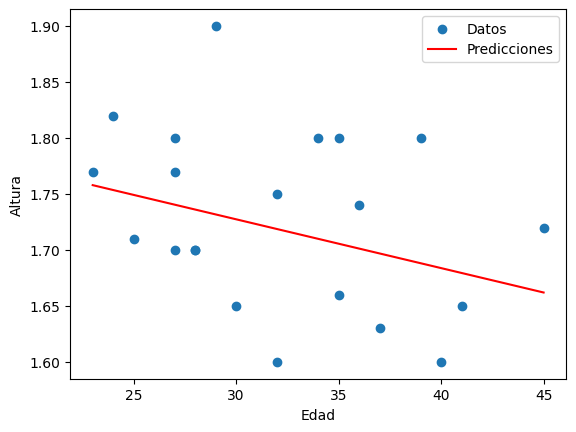

In [47]:
import numpy as np
import matplotlib.pyplot as plt

y_pred_total = modelo.predict(X)

orden = np.argsort(X["Edad"].values)

plt.scatter(X["Edad"], y, label="Datos")
plt.plot(X["Edad"].values[orden], y_pred_total[orden], color="red", label="Predicciones")

plt.xlabel("Edad")
plt.ylabel("Altura")
plt.legend()
plt.show()

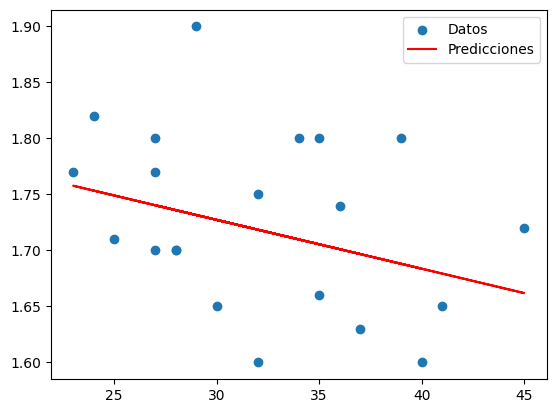

,Edad,prediccion,valor_real,error,error_cuad
0,24,1.753478,1.82,0.066522,0.004425
17,34,1.709906,1.80,0.090094,0.008117
15,32,1.718621,1.75,0.031379,0.000985
1,25,1.749121,1.71,0.039121,0.001530
8,36,1.701192,1.74,0.038808,0.001506


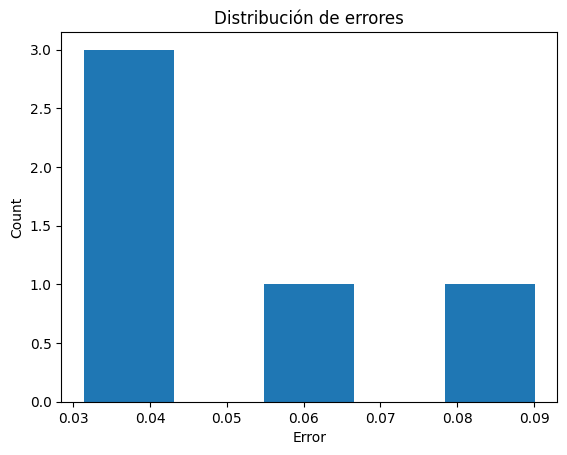

In [50]:
plt.hist(tabla["error"], bins=5)

plt.xlabel("Error")
plt.ylabel("Count")
plt.title("Distribución de errores")

plt.show()

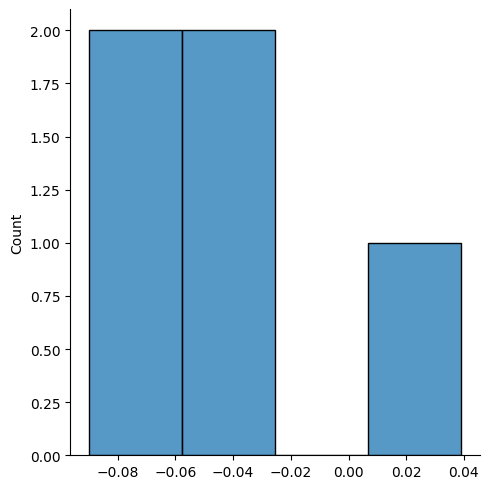